## More stats to validate the results

### Bland–Altman plot
A Bland–Altman plot (also called a difference plot) is a method to compare two measurement techniques or two sets of measurements of the same variable — for example, comparing a new medical imaging algorithm’s output to a gold-standard method.

In [1]:
# the data i needed, final results
## cropped size (63, 50, 61)
## fc - /data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/09Jul2024-12:12:48-trainID-33.3
## final_Y_test_pred.npy, Y_test_true.npy, res_test.npy
## dsnt - "/data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/u_net_dsnt/turner_results/random_grid_0/14Aug2024-04:36:02-trainID-13.1"
import os
import numpy as np

ret_dir = "/data/gpfs/projects/punim1836/CT-MRI_LandmarkDetection/models/cropped/63x50x61/noises_s1_test_dis/two_landmarks/straight_model/turner-results/training-process/09Jul2024-12:12:48-trainID-33.3"
y_test_true = np.load(os.path.join(ret_dir, "Y_test_true.npy"))
y_test_pred = np.load(os.path.join(ret_dir, "final_Y_test_pred.npy"))
res_test = np.load(os.path.join(ret_dir, "res_test.npy"))

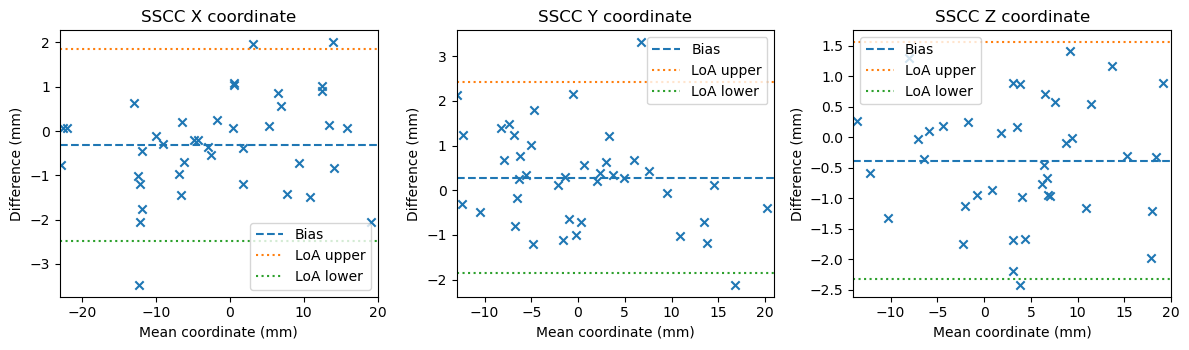

In [2]:
# the stats functions
import numpy as np
import matplotlib.pyplot as plt

def bland_altman_basic(ob1, ob2, ax=None, title="Bland–Altman", xlab="Mean", ylab="Diff"):
    """
    Basic Bland–Altman for 1D paired data.
    Draws bias and limits of agreement (±1.96*SD). Returns (fig, ax).
    """
    ob1 = np.asarray(ob1, float).ravel()
    ob2 = np.asarray(ob2, float).ravel()
    if ob1.size != ob2.size or ob1.size < 3:
        raise ValueError("Need >=3 paired observations with equal length.")

    mean_ob = (ob1 + ob2) / 2.0
    diff_ob = ob1 - ob2
    bias = np.mean(diff_ob)
    sd   = np.std(diff_ob, ddof=1)
    loa_upper = bias + 1.96 * sd
    loa_lower = bias - 1.96 * sd

    created = False
    if ax is None:
        fig, ax = plt.subplots()
        created = True
    else:
        fig = ax.figure

    ax.scatter(mean_ob, diff_ob, marker='x')          # keep default colors
    x_min, x_max = np.floor(mean_ob.min()), np.ceil(mean_ob.max())
    ax.plot([x_min, x_max], [bias, bias], linestyle='--', label="Bias")
    ax.plot([x_min, x_max], [loa_upper, loa_upper], linestyle=':', label="LoA upper")
    ax.plot([x_min, x_max], [loa_lower, loa_lower], linestyle=':', label="LoA lower")
    ax.set_xlim(x_min, x_max)
    y_min = min(diff_ob.min(), loa_lower)
    y_max = max(diff_ob.max(), loa_upper)
    pad = 0.05 * max(1.0, (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend()
    return fig, ax


def bland_altman_3d_per_axis(pts1_mm, pts2_mm, roi_name="ROI"):
    """
    Basic per-axis Bland–Altman for 3D landmarks.
    pts*_mm: arrays of shape (N, 3) in millimetres, matched point-wise.
    Returns (fig, axes).
    """
    pts1_mm = np.asarray(pts1_mm, float)
    pts2_mm = np.asarray(pts2_mm, float)
    if pts1_mm.shape != pts2_mm.shape or pts1_mm.ndim != 2 or pts1_mm.shape[1] != 3:
        raise ValueError("pts1_mm and pts2_mm must be (N, 3) arrays.")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    labels = ["X", "Y", "Z"]

    for i, lab in enumerate(labels):
        bland_altman_basic(
            pts1_mm[:, i],
            pts2_mm[:, i],
            ax=axes[i],
            title=f"{roi_name} {lab} coordinate",
            xlab="Mean coordinate (mm)",
            ylab="Difference (mm)",
        )
    fig.tight_layout()
    return fig, axes

# ---- tiny example ----
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    # fake 3D points (N,3)
    p1 = rng.normal(0, 10, size=(40, 3))
    p2 = p1 + np.array([0.4, -0.2, 0.6]) + rng.normal(0, 1.0, size=(40, 3))
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="SSCC")
    plt.show()


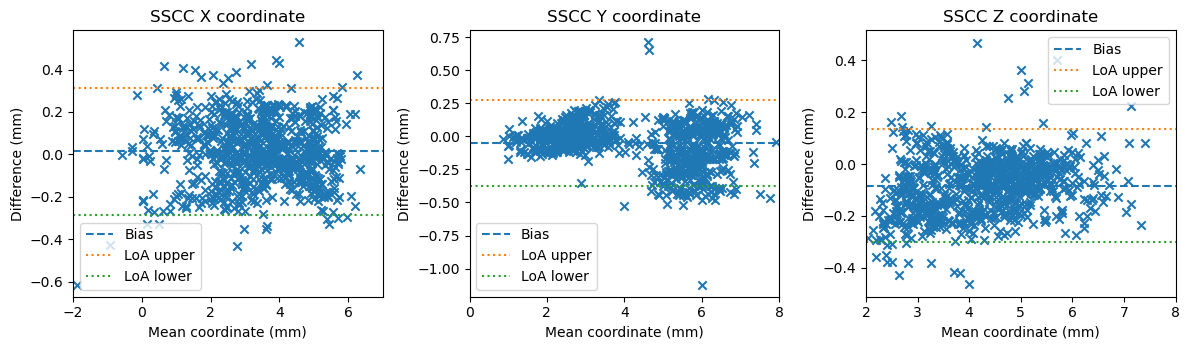

In [4]:
if __name__ == "__main__":
    # 3D points (N,3)
    p1 = y_test_true.reshape(-1, 3) * 0.15
    p2 = y_test_pred.reshape(-1, 3) * 0.15
    fig, axes = bland_altman_3d_per_axis(p1, p2, roi_name="SSCC")
    plt.show()

In [ ]:
# plot the results

### Confidence intervals

### hypothesis testing